<a href="https://colab.research.google.com/github/jonkrohn/ML-foundations/blob/master/notebooks/2-linear-algebra-ii.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Algebra II: Matrix Operations

This topic, *Linear Algebra II: Matrix Operations*, builds on the basics of linear algebra. It is essential because these intermediate-level manipulations of tensors lie at the heart of most machine learning approaches and are especially predominant in deep learning. 

Through the measured exposition of theory paired with interactive examples, you’ll develop an understanding of how linear algebra is used to solve for unknown values in high-dimensional spaces as well as to reduce the dimensionality of complex spaces. The content covered in this topic is itself foundational for several other topics in the *Machine Learning Foundations* series, especially *Probability & Information Theory* and *Optimization*. 

Over the course of studying this topic, you'll: 

* Develop a geometric intuition of what’s going on beneath the hood of machine learning algorithms, including those used for deep learning. 
* Be able to more intimately grasp the details of machine learning papers as well as all of the other subjects that underlie ML, including calculus, statistics, and optimization algorithms. 
* Reduce the dimensionalty of complex spaces down to their most informative elements with techniques such as eigendecomposition, singular value decomposition, and principal component analysis.

**Note that this Jupyter notebook is not intended to stand alone. It is the companion code to a lecture or to videos from Jon Krohn's [Machine Learning Foundations](https://github.com/jonkrohn/ML-foundations) series, which offer detail on the following:**

*Review of Introductory Linear Algebra*

* Modern Linear Algebra Applications
* Tensors, Vectors, and Norms
* Matrix Multiplication
* Matrix Inversion
* Identity, Diagonal and Orthogonal Matrices

*Segment 2: Eigendecomposition*

* Affine Transformation via Matrix Application
* Eigenvectors and Eigenvalues
* Matrix Determinants
* Matrix Decomposition 
* Applications of Eigendecomposition

*Segment 3: Matrix Operations for Machine Learning*

* Singular Value Decomposition (SVD)
* The Moore-Penrose Pseudoinverse
* The Trace Operator
* Principal Component Analysis (PCA): A Simple Machine Learning Algorithm
* Resources for Further Study of Linear Algebra

## Segment 2: Eigendecomposition

### Affine Transformation via Matrix Application

Let's say we have a vector $v$:

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [6]:
v = np.array([3, 1])
v

array([3, 1])

Let's plot $v$ using my `plot_vectors()` function (which is based on Hadrien Jean's `plotVectors()` function from [this notebook](https://github.com/hadrienj/deepLearningBook-Notes/blob/master/2.7%20Eigendecomposition/2.7%20Eigendecomposition.ipynb), under [MIT license](https://github.com/hadrienj/deepLearningBook-Notes/blob/master/LICENSE)).

In [7]:
import matplotlib.pyplot as plt

In [8]:
def plot_vectors(vectors, colors):
    """
    Plot one or more vectors in a 2D plane, specifying a color for each. 

    Arguments
    ---------
    vectors: list of lists or of arrays
        Coordinates of the vectors to plot. For example, [[1, 3], [2, 2]] 
        contains two vectors to plot, [1, 3] and [2, 2].
    colors: list
        Colors of the vectors. For instance: ['red', 'blue'] will display the
        first vector in red and the second in blue.
        
    Example
    -------
    plot_vectors([[1, 3], [2, 2]], ['red', 'blue'])
    plt.xlim(-1, 4)
    plt.ylim(-1, 4)
    """
    plt.figure()
    plt.axvline(x=0, color='lightgray')
    plt.axhline(y=0, color='lightgray')

    for i in range(len(vectors)):
        x = np.concatenate([[0,0],vectors[i]])
        plt.quiver([x[0]], [x[1]], [x[2]], [x[3]],
                   angles='xy', scale_units='xy', scale=1, color=colors[i],)

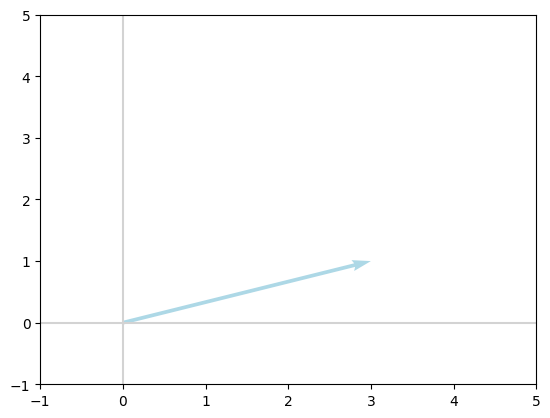

In [9]:
plot_vectors([v], ['lightblue'])
plt.xlim(-1, 5)
_ = plt.ylim(-1, 5)

"Applying" a matrix to a vector (i.e., performing matrix-vector multiplication) can linearly transform the vector, **e.g, rotate it or rescale it.**

The identity matrix, introduced earlier, is the exception that proves the rule: Applying an identity matrix does not transform the vector: 

In [10]:
I = np.array([[1, 0], [0, 1]])
I

array([[1, 0],
       [0, 1]])

In [11]:
Iv = np.dot(I, v)
Iv

array([3, 1])

In [12]:
v == Iv

array([ True,  True])

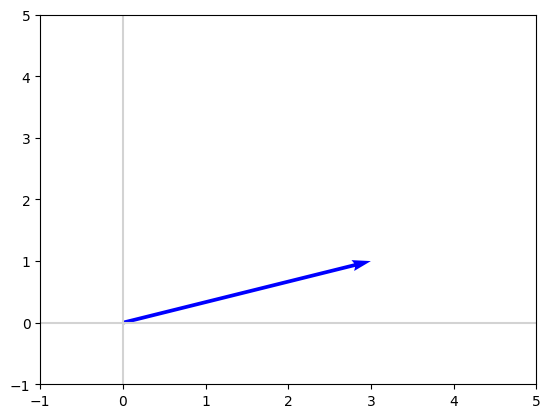

In [13]:
plot_vectors([Iv], ['blue'])
plt.xlim(-1, 5)
_ = plt.ylim(-1, 5)

In contrast, consider this matrix (let's call it $E$) that flips vectors over the $x$-axis: 

In [14]:
E = np.array([[1, 0], [0, -1]])
E

array([[ 1,  0],
       [ 0, -1]])

In [15]:
Ev = np.dot(E, v)
Ev

array([ 3, -1])

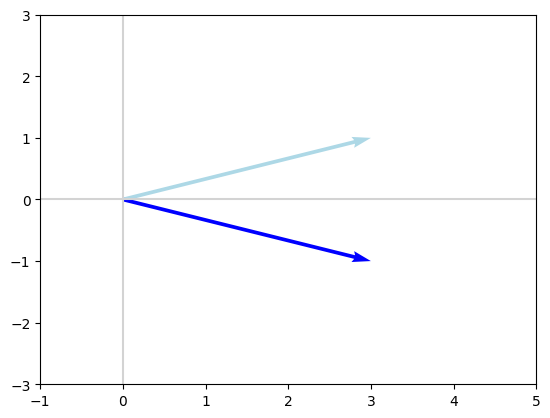

In [16]:
plot_vectors([v, Ev], ['lightblue', 'blue'])
plt.xlim(-1, 5)
_ = plt.ylim(-3, 3)

Or, this matrix, $F$, which flips vectors over the $y$-axis: 

In [17]:
F = np.array([[-1, 0], [0, 1]])
F 

array([[-1,  0],
       [ 0,  1]])

In [18]:
Fv = np.dot(F, v)
Fv

array([-3,  1])

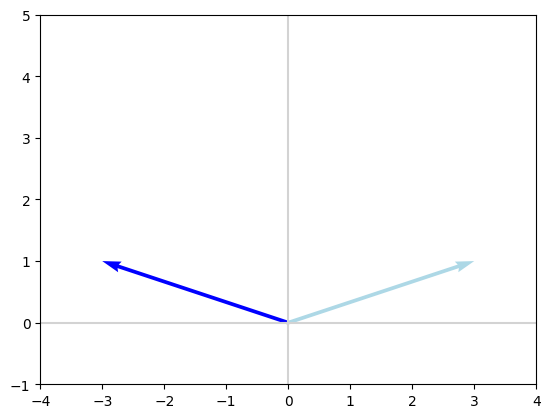

In [19]:
plot_vectors([v, Fv], ['lightblue', 'blue'])
plt.xlim(-4, 4)
_ = plt.ylim(-1, 5)

Applying a flipping matrix is an example of an **affine transformation**: a change in geometry that may adjust distances or angles between vectors, but preserves parallelism between them.

In addition to flipping a matrix over an axis (a.k.a., *reflection*), other common affine transformations include:
* *Scaling* (changing the length of vectors)
* *Shearing* (example of this on the Mona Lisa coming up shortly)
* *Rotation* 

(See [here](https://stackabuse.com/affine-image-transformations-in-python-with-numpy-pillow-and-opencv/) for an outstanding blog post on affine transformations in Python, including how to apply them to images as well as vectors.)

A single matrix can apply multiple affine transforms simultaneously (e.g., flip over an axis and rotate 45 degrees). As an example, let's see what happens when we apply this matrix $A$ to the vector $v$: 

In [20]:
A = np.array([[-1, 4], [2, -2]])
A

array([[-1,  4],
       [ 2, -2]])

In [21]:
Av = np.dot(A, v)
Av

array([1, 4])

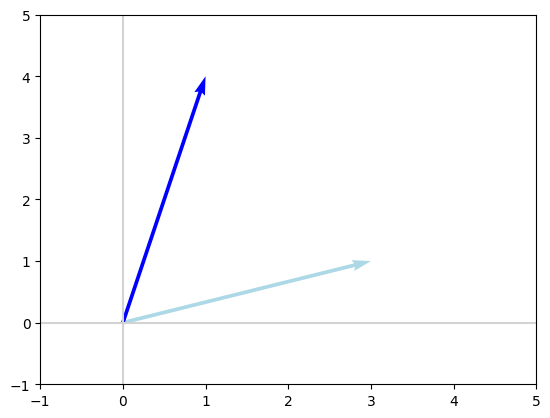

In [22]:
plot_vectors([v, Av], ['lightblue', 'blue'])
plt.xlim(-1, 5)
_ = plt.ylim(-1, 5)

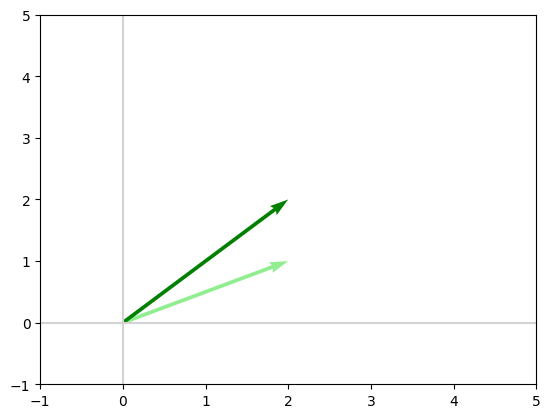

In [23]:
# Another example of applying A:
v2 = np.array([2, 1])
plot_vectors([v2, np.dot(A, v2)], ['lightgreen', 'green'])
plt.xlim(-1, 5)
_ = plt.ylim(-1, 5)

We can concatenate several vectors together into a matrix (say, $V$), where each column is a separate vector. Then, whatever linear transformations we apply to $V$ will be independently applied to each column (vector): 

In [24]:
v

array([3, 1])

In [25]:
# recall that we need to convert array to 2D to transpose into column, e.g.:
np.matrix(v).T 

matrix([[3],
        [1]])

In [26]:
v3 = np.array([-3, -1]) # mirror image of v over both axes
v4 = np.array([-1, 1])

In [27]:
V = np.concatenate((np.matrix(v).T, 
                    np.matrix(v2).T,
                    np.matrix(v3).T,
                    np.matrix(v4).T), 
                   axis=1)
V

matrix([[ 3,  2, -3, -1],
        [ 1,  1, -1,  1]])

In [28]:
IV = np.dot(I, V)
IV

matrix([[ 3,  2, -3, -1],
        [ 1,  1, -1,  1]])

In [29]:
AV = np.dot(A, V)
AV

matrix([[ 1,  2, -1,  5],
        [ 4,  2, -4, -4]])

In [30]:
# function to convert column of matrix to 1D vector: 
def vectorfy(mtrx, clmn):
    return np.array(mtrx[:,clmn]).reshape(-1)

In [31]:
vectorfy(V, 0)

array([3, 1])

In [32]:
vectorfy(V, 0) == v

array([ True,  True])

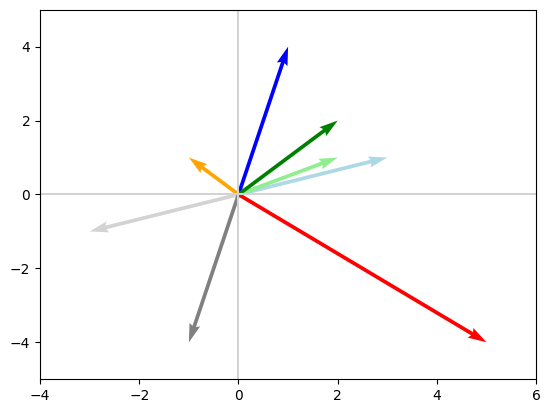

In [33]:
plot_vectors([vectorfy(V, 0), vectorfy(V, 1), vectorfy(V, 2), vectorfy(V, 3),
             vectorfy(AV, 0), vectorfy(AV, 1), vectorfy(AV, 2), vectorfy(AV, 3)], 
            ['lightblue', 'lightgreen', 'lightgray', 'orange',
             'blue', 'green', 'gray', 'red'])
plt.xlim(-4, 6)
_ = plt.ylim(-5, 5)

Now that we can appreciate the linear transformation of vectors by matrices, let's move on to working with eigenvectors and eigenvalues...

**Return to slides here.**

### Eigenvectors and Eigenvalues

An **eigenvector** (*eigen* is German for "own" or "characteristics"; we could translate *eigenvector* to "characteristic vector").

An **eigenvector** of a square matrix $A$ is a **nonzero vector** $v$ such that applying the linear transformation $A$  to $v$ results only in scaling by a scalar $\lambda$:

$$Av = \lambda v,$$

where $\lambda$ is called the **eigenvalue**. It tells how much the eigenvector's length has changed.

In other words, an eigenvector is a vector whose image under the transformation remains **parallel to itself**—its magnitude may change, and its orientation may reverse if $\lambda < 0$, but it does not rotate into a different direction (i.e., it stays within the same one-dimensional subspace).

$A$ must be a square matrix because only a square matrix maps a vector space to itself, allowing $Av$ to be compared directly with $v$ in the equation  $Av = \lambda v$.

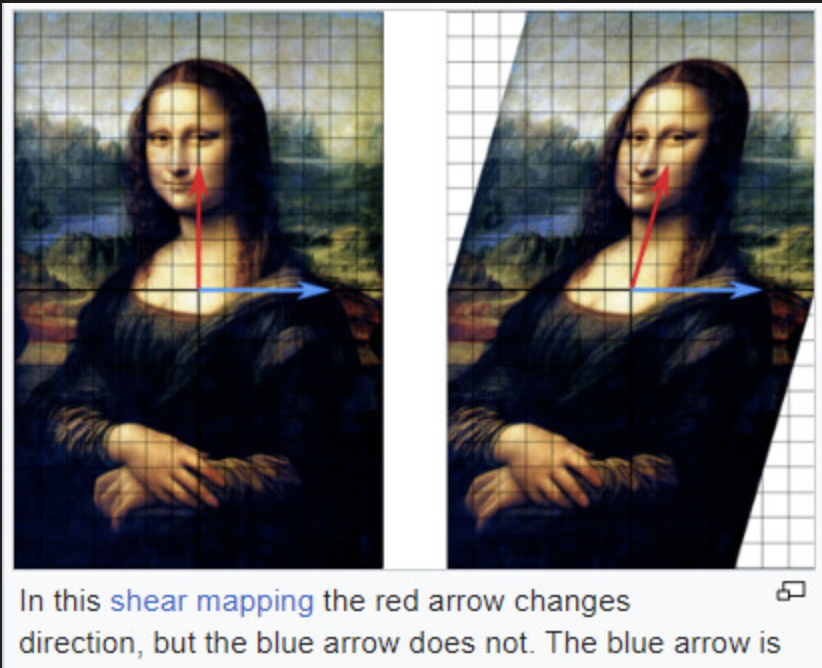

Easiest way to understand this is to work through an example: 

In [34]:
A

array([[-1,  4],
       [ 2, -2]])

Eigenvectors and eigenvalues can be derived algebraically (e.g., with the [QR algorithm](https://en.wikipedia.org/wiki/QR_algorithm), which was independently developed in the 1950s by both [Vera Kublanovskaya](https://en.wikipedia.org/wiki/Vera_Kublanovskaya) and John Francis), however this is outside scope of the *ML Foundations* series. We'll cheat with NumPy `eig()` method, which returns a tuple of: 

* a vector of eigenvalues
* a matrix of eigenvectors

In [35]:
lambdas, V = np.linalg.eig(A) 

The matrix contains as many eigenvectors as there are columns of A: 

In [36]:
V # each column is a separate eigenvector v

array([[ 0.86011126, -0.76454754],
       [ 0.51010647,  0.64456735]])

With a corresponding eigenvalue for each eigenvector:

In [37]:
lambdas

array([ 1.37228132, -4.37228132])

Let's confirm that $Av = \lambda v$ for the first eigenvector: 

In [38]:
v = V[:,0] 
v

array([0.86011126, 0.51010647])

In [39]:
lambduh = lambdas[0] # note that "lambda" is reserved term in Python
lambduh

1.3722813232690143

In [40]:
Av = np.dot(A, v)
Av

array([1.18031462, 0.70000958])

In [41]:
lambduh * v

array([1.18031462, 0.70000958])

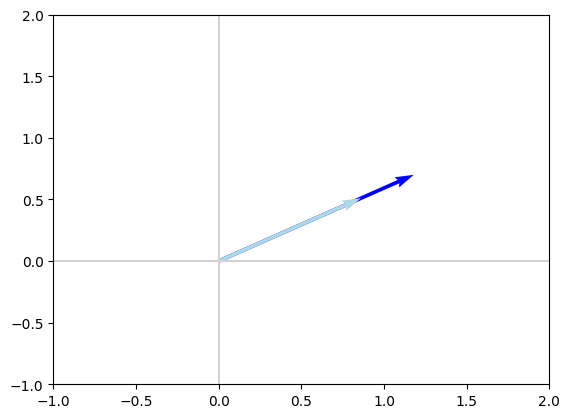

In [42]:
plot_vectors([Av, v], ['blue', 'lightblue'])
plt.xlim(-1, 2)
_ = plt.ylim(-1, 2)

And again for the second eigenvector of A: 

In [43]:
v2 = V[:,1]
v2

array([-0.76454754,  0.64456735])

In [44]:
lambda2 = lambdas[1]
lambda2

-4.372281323269014

In [45]:
Av2 = np.dot(A, v2)
Av2

array([ 3.34281692, -2.81822977])

In [46]:
lambda2 * v2

array([ 3.34281692, -2.81822977])

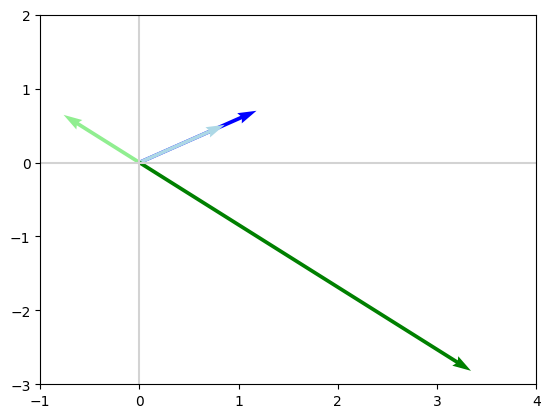

In [47]:
plot_vectors([Av, v, Av2, v2], 
            ['blue', 'lightblue', 'green', 'lightgreen'])
plt.xlim(-1, 4)
_ = plt.ylim(-3, 2)

Using the **PyTorch `eig()` method**, we can do exactly the same: 

In [48]:
A

array([[-1,  4],
       [ 2, -2]])

In [49]:
A_p = torch.tensor([[-1, 4], [2, -2.]]) # must be float for PyTorch eig()
A_p

tensor([[-1.,  4.],
        [ 2., -2.]])

In [50]:
lambdas_cplx, V_cplx = torch.linalg.eig(A_p) # outputs complex numbers because real matrices can have complex eigenvectors

In [51]:
V_cplx # complex-typed values with "0.j" imaginary part are in fact real numbers

tensor([[ 0.8601+0.j, -0.7645+0.j],
        [ 0.5101+0.j,  0.6446+0.j]])

In [52]:
V_p = V_cplx.float() # convert to float, which drops the imaginary part (since it's zero)
V_p

/var/folders/sd/6w8v27q940q9w4jwh6y88y980000gn/T/ipykernel_64517/1370097596.py:1: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Copy.cpp:301.)
  V_p = V_cplx.float() # convert to float, which drops the imaginary part (since it's zero)


tensor([[ 0.8601, -0.7645],
        [ 0.5101,  0.6446]])

In [53]:
v_p = V_p[:,0]
v_p

tensor([0.8601, 0.5101])

In [54]:
lambdas_cplx

tensor([ 1.3723+0.j, -4.3723+0.j])

In [55]:
lambdas_p = lambdas_cplx.float()
lambdas_p

tensor([ 1.3723, -4.3723])

In [56]:
lambda_p = lambdas_p[0]
lambda_p

tensor(1.3723)

In [57]:
Av_p = torch.matmul(A_p, v_p) # matmul() expects float-typed tensors
Av_p

tensor([1.1803, 0.7000])

In [58]:
lambda_p * v_p

tensor([1.1803, 0.7000])

In [59]:
v2_p = V_p[:,1]
v2_p

tensor([-0.7645,  0.6446])

In [60]:
lambda2_p = lambdas_p[1]
lambda2_p

tensor(-4.3723)

In [61]:
Av2_p = torch.matmul(A_p.float(), v2_p.float())
Av2_p

tensor([ 3.3428, -2.8182])

In [62]:
lambda2_p.float() * v2_p.float()

tensor([ 3.3428, -2.8182])

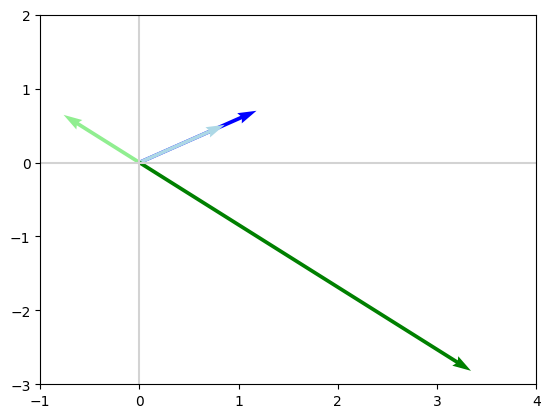

In [63]:
plot_vectors([Av_p.numpy(), v_p.numpy(), Av2_p.numpy(), v2_p.numpy()], 
            ['blue', 'lightblue', 'green', 'lightgreen'])
plt.xlim(-1, 4)
_ = plt.ylim(-3, 2)

### Eigenvectors in >2 Dimensions

While plotting gets trickier in higher-dimensional spaces, we can nevertheless find and use eigenvectors with more than two dimensions. Here's a 3D example (there are three dimensions handled over three rows): 

In [64]:
X = np.array([[25, 2, 9], [5, 26, -5], [3, 7, -1]])
X

array([[25,  2,  9],
       [ 5, 26, -5],
       [ 3,  7, -1]])

In [65]:
lambdas_X, V_X = np.linalg.eig(X) 

In [66]:
V_X # one eigenvector per column of X

array([[-0.71175736, -0.6501921 , -0.34220476],
       [-0.66652125,  0.74464056,  0.23789717],
       [-0.22170001,  0.15086635,  0.90901091]])

In [67]:
lambdas_X # a corresponding eigenvalue for each eigenvector

array([29.67623202, 20.62117365, -0.29740567])

Confirm $Xv = \lambda v$ for an example eigenvector: 

In [68]:
v_X = V_X[:,0] 
v_X

array([-0.71175736, -0.66652125, -0.22170001])

In [69]:
lambda_X = lambdas_X[0] 
lambda_X

29.676232023948902

In [70]:
np.dot(X, v_X) # matrix multiplication

array([-21.12227645, -19.77983919,  -6.5792208 ])

In [71]:
np.matmul(X, v_X) # same as np.dot() for 2D arrays

array([-21.12227645, -19.77983919,  -6.5792208 ])

In [72]:
X @ v_X # same as np.dot() and np.matmul() for 2D arrays

array([-21.12227645, -19.77983919,  -6.5792208 ])

In [73]:
lambda_X * v_X

array([-21.12227645, -19.77983919,  -6.5792208 ])

**Exercises**:

1. Use PyTorch to confirm $Xv = \lambda v$ for the first eigenvector of $X$.
2. Confirm $Xv = \lambda v$ for the remaining eigenvectors of $X$ (you can use NumPy or PyTorch, whichever you prefer).

**Answers**

In [74]:
X_pytorch = torch.from_numpy(X).float() 
X_pytorch

tensor([[25.,  2.,  9.],
        [ 5., 26., -5.],
        [ 3.,  7., -1.]])

In [75]:
lambdas_x, V_torch = torch.linalg.eig(X_pytorch)
lambdas = lambdas_x.float()
V_torch = V_torch.float()

In [76]:
V_torch

tensor([[ 0.7118,  0.6502, -0.3422],
        [ 0.6665, -0.7446,  0.2379],
        [ 0.2217, -0.1509,  0.9090]])

In [77]:
lambdas

tensor([29.6762, 20.6212, -0.2974])

In [78]:
torch.matmul(X_pytorch, V_torch[:,0]) # matrix multiplication

tensor([21.1223, 19.7798,  6.5792])

In [79]:
lambdas[0] * V_torch[:,0]

tensor([21.1223, 19.7798,  6.5792])

**Return to slides here.**

## Matrix Determinants
A **determinant** is a scalar that summarizes key properties of a square matrix:

- **Area/volume scaling**: For a 2D/3D linear transformation, the determinant gives the factor by which area/volume is scaled.  
- **Orientation**: A negative determinant indicates a **reflection** (orientation flip).  
- **Invertibility**: A matrix is **invertible** if its determinant is nonzero.

If $\det(A) = 0$:
- A zero determinant indicates the situation where we have no solution or infinite solutions. A matrix $A$ with determinant $0$, its $A^{-1}$ has $1/\det(A) = 1/0.$
- The martix A is singular: It contains linearly-independent columns


For a $2 \times 2$ matrix  
$$
A = \begin{bmatrix} a & b \\ c & d \end{bmatrix},
$$
the determinant is
$$
\det(A) = ad - bc.
$$

In higher dimensions, the determinant generalizes these ideas and can be computed with numerical tools like NumPy or PyTorch.

### 2x2 Matrix Determinants

In [80]:
X = np.array([[4, 2], [-5, -3]])
X

array([[ 4,  2],
       [-5, -3]])

In [81]:
np.linalg.det(X)

-2.0000000000000013

**Return to slides here.**

In [82]:
N = np.array([[-4, 1], [-8, 2]])
N

array([[-4,  1],
       [-8,  2]])

In [83]:
np.linalg.det(N)

0.0

In [84]:
# Uncommenting the following line results in a "singular matrix" error
# Ninv = np.linalg.inv(N)

In [85]:
N = torch.tensor([[-4, 1], [-8, 2.]]) # must use float not int

In [86]:
torch.det(N) 

tensor(-0.)

**Return to slides here.**

### Generalizing Determinants
Use recursion to calculate determinants of larger matrices (greater than $2 \times 2$):

Expand along any row or column using **cofactor (Laplace) expansion**. Each term uses a minor (remove the row and column) and alternates signs:
$$
\det(A)=\sum_{j=1}^{n}(-1)^{i+j}a_{ij}\det(M_{ij}),
$$
with the recursion ending at the \$2\times2\$ case \(\det\begin{bmatrix}a&b\\c&d\end{bmatrix}=ad-bc\).

#### 5×5 Determinant (General Form)
Let
$$
X=\begin{bmatrix}
x_{1,1}&x_{1,2}&x_{1,3}&x_{1,4}&x_{1,5}\\
x_{2,1}&x_{2,2}&x_{2,3}&x_{2,4}&x_{2,5}\\
x_{3,1}&x_{3,2}&x_{3,3}&x_{3,4}&x_{3,5}\\
x_{4,1}&x_{4,2}&x_{4,3}&x_{4,4}&x_{4,5}\\
x_{5,1}&x_{5,2}&x_{5,3}&x_{5,4}&x_{5,5}
\end{bmatrix}.
$$
Expanding along row $i$ (Laplace expansion):
$$
\det(X)=\sum_{j=1}^{5}(-1)^{i+j}\,x_{i,j}\,\det(M_{ij}),
$$
where $M_{ij}$ is the $4\times4$ minor obtained by deleting row $i$ and column $j$.
(For the first row, set $i=1$.)

In [87]:
X = np.array([[1, 2, 4], [2, -1, 3], [0, 5, 1]])
X

array([[ 1,  2,  4],
       [ 2, -1,  3],
       [ 0,  5,  1]])

In [88]:
np.linalg.det(X)

19.999999999999996

**Return to slides here.**

### Determinants & Eigenvalues

The determinant equals the product of eigenvalues (counted with algebraic multiplicity):

$$\det(X)=\prod_{i=1}^{n}\lambda_i.$$

So if any eigenvalue is 0, the determinant is 0 (matrix is singular).
$|\det(X)|$ quantifies the volume change as a result of applying matrix $X$ to some tensor:
- $|\det(X)| > 1$: volume expands by a factor of $|\det(X)|$.
- $|\det(X)| = 1$: volume is preserved (pure rotation/shear/reflection).
- $0 < |\det(X)| < 1$: volume shrinks by a factor of $|\det(X)|$.
- $\det(X) = 0$: volume collapses to zero (at least one dimension is flattened).
- $\det(X) < 0$: orientation flips (reflection), while the scale factor is $|\det(X)|$.

In [89]:
lambdas, V = np.linalg.eig(X)
lambdas

array([-3.25599251, -1.13863631,  5.39462882])

In [90]:
np.product(lambdas)

19.99999999999999

**Return to slides here.**

Here's $|\text{det}(X)|$ in NumPy: 

In [91]:
np.abs(np.linalg.det(X))

19.999999999999996

Let's use a matrix $B$, which is composed of basis vectors, to explore the impact of applying matrices with varying $|\text{det}(X)|$ values: 

In [92]:
B = np.array([[1, 0], [0, 1]])
B

array([[1, 0],
       [0, 1]])

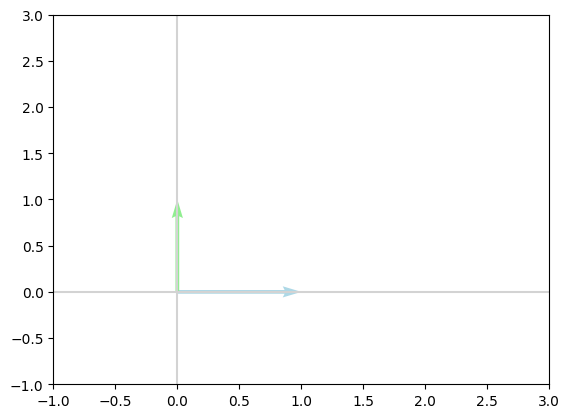

In [93]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1)],
            ['lightblue', 'lightgreen'])
plt.xlim(-1, 3)
_ = plt.ylim(-1, 3)

Let's start by applying the matrix $N$ to $B$, recalling from earlier that $N$ is singular (determinant is zero): 

In [94]:
N

tensor([[-4.,  1.],
        [-8.,  2.]])

In [95]:
np.linalg.det(N)

0.0

In [96]:
NB = np.dot(N, B)
NB

array([[-4.,  1.],
       [-8.,  2.]])

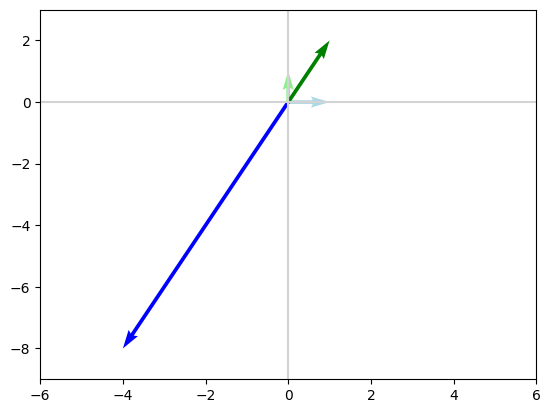

In [97]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1), vectorfy(NB, 0), vectorfy(NB, 1)],
            ['lightblue', 'lightgreen', 'blue', 'green'])
plt.xlim(-6, 6)
_ = plt.ylim(-9, 3)

It basically collapsed the volume (volument between the two unit vectors) making it a straight line.

In [98]:
lambdas, V = np.linalg.eig(N)
lambdas

array([-2.,  0.], dtype=float32)

Aha! If any one of a matrix's eigenvalues is zero, then the product of the eigenvalues must be zero and the determinant must also be zero. 

Now let's try applying $I_2$ to $B$: 

In [99]:
I

array([[1, 0],
       [0, 1]])

In [100]:
np.linalg.det(I)

1.0

In [101]:
IB = np.dot(I, B)
IB

array([[1, 0],
       [0, 1]])

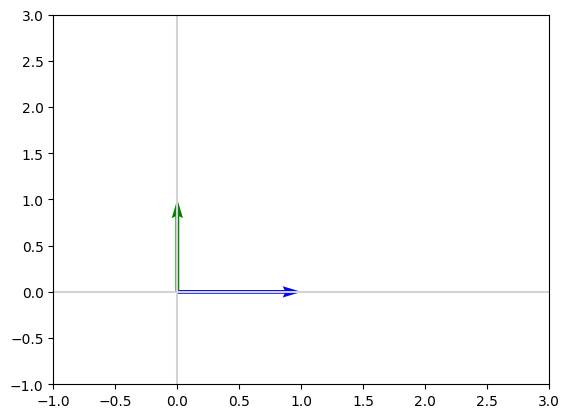

In [102]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1), vectorfy(IB, 0), vectorfy(IB, 1)],
            ['lightblue', 'lightgreen', 'blue', 'green'])
plt.xlim(-1, 3)
_ = plt.ylim(-1, 3)

In [103]:
lambdas, V = np.linalg.eig(I)
lambdas

array([1., 1.])

All right, so applying an identity matrix isn't the most exciting operation in the world. Let's now apply this matrix $J$ which is more interesting: 

In [104]:
J = np.array([[-0.5, 0], [0, 2]])
J

array([[-0.5,  0. ],
       [ 0. ,  2. ]])

In [105]:
np.linalg.det(J)

-1.0

In [106]:
np.abs(np.linalg.det(J))

1.0

In [107]:
JB = np.dot(J, B)
JB

array([[-0.5,  0. ],
       [ 0. ,  2. ]])

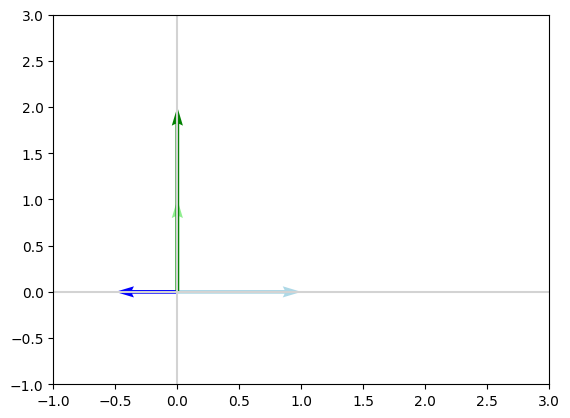

In [108]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1), vectorfy(JB, 0), vectorfy(JB, 1)],
            ['lightblue', 'lightgreen', 'blue', 'green'])
plt.xlim(-1, 3)
_ = plt.ylim(-1, 3)

The above means that basis vectors are the eigen vectors of the matrix J (they remain on their spans). Check the eigen values of each vector below. Pay attention that the volume is still equal (|det(X)| = 1)

In [109]:
lambdas, V = np.linalg.eig(J)
lambdas

array([-0.5,  2. ])

Finally, let's apply the matrix $D$, which scales vectors by doubling along both the $x$ and $y$ axes: 

In [110]:
D = I*2
D

array([[2, 0],
       [0, 2]])

In [111]:
np.linalg.det(D)

4.0

In [112]:
DB = np.dot(D, B)
DB

array([[2, 0],
       [0, 2]])

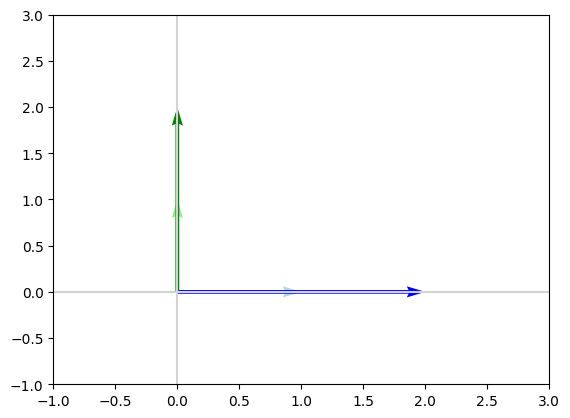

In [113]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1), vectorfy(DB, 0), vectorfy(DB, 1)],
            ['lightblue', 'lightgreen', 'blue', 'green'])
plt.xlim(-1, 3)
_ = plt.ylim(-1, 3)

In [114]:
lambdas, V = np.linalg.eig(D)
lambdas

array([2., 2.])

The volume is doubled.
**Return to slides here.**

### Eigendecomposition

The **eigendecomposition** of some matrix $A$ is 

$A = V \Lambda V^{-1}$

Where: 

* As in examples above, $V$ is the concatenation of all the eigenvectors of $A$
* $\Lambda$ (upper-case $\lambda$) is the diagonal matrix diag($\lambda$) of the eigenvalues of $A$. Note that the convention is to arrange the lambda values in descending order; as a result, the first eigenvalue (and its associated eigenvector) may be a primary characteristic of the matrix $A$.

The decompostion of a matrix into eigenvectors and eigenvalues reveals:
- A matrix is singular if any of its eigenvalues are zero
- Under specific conditions, can optimize quadratic equations
  - Maximum of $f(x)$ = largest eigenvalue
  - Minimum of $f(x)$ = smalled eigenvalue

In [115]:
# This was used earlier as a matrix X; it has nice clean integer eigenvalues...
A = np.array([[4, 2], [-5, -3]]) 
A

array([[ 4,  2],
       [-5, -3]])

In [116]:
lambdas, V = np.linalg.eig(A)

In [117]:
V

array([[ 0.70710678, -0.37139068],
       [-0.70710678,  0.92847669]])

In [118]:
Vinv = np.linalg.inv(V)
Vinv

array([[2.3570226 , 0.94280904],
       [1.79505494, 1.79505494]])

In [119]:
Lambda = np.diag(lambdas)
Lambda

array([[ 2.,  0.],
       [ 0., -1.]])

Confirm that $A = V \Lambda V^{-1}$: 

In [120]:
np.dot(V, np.dot(Lambda, Vinv))

array([[ 4.,  2.],
       [-5., -3.]])

Eigendecomposition is not possible with all matrices. And in some cases where it is possible, the eigendecomposition involves complex numbers instead of straightforward real numbers. 

In machine learning, however, we are typically working with real symmetric matrices, which can be conveniently and efficiently decomposed into real-only eigenvectors and real-only eigenvalues. If $A$ is a real symmetric matrix then...

$A = Q \Lambda Q^T$

...where $Q$ is analogous to $V$ from the previous equation except that it's special because it's an orthogonal matrix. 

In [121]:
A = np.array([[2, 1], [1, 2]])
A

array([[2, 1],
       [1, 2]])

In [122]:
lambdas, Q = np.linalg.eig(A)

In [123]:
lambdas

array([3., 1.])

In [124]:
Lambda = np.diag(lambdas)
Lambda

array([[3., 0.],
       [0., 1.]])

In [125]:
Q

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

Let's confirm $A = Q \Lambda Q^T$: 

In [126]:
np.dot(Q, np.dot(Lambda, Q.T))

array([[2., 1.],
       [1., 2.]])

(As a quick aside, we can demostrate that $Q$ is an orthogonal matrix because $Q^TQ = QQ^T = I$.)

In [127]:
np.dot(Q.T, Q)

array([[1.00000000e+00, 2.23711432e-17],
       [2.23711432e-17, 1.00000000e+00]])

In [128]:
np.dot(Q, Q.T)

array([[ 1.00000000e+00, -2.23711432e-17],
       [-2.23711432e-17,  1.00000000e+00]])

**Exercises**:

1. Use PyTorch to decompose the matrix $P$ (below) into its components $V$, $\Lambda$, and $V^{-1}$. Confirm that $P = V \Lambda V^{-1}$.
2. Use PyTorch to decompose the symmetric matrix $S$ (below) into its components $Q$, $\Lambda$, and $Q^T$. Confirm that $S = Q \Lambda Q^T$.

In [129]:
P = torch.tensor([[25, 2, -5], [3, -2, 1], [5, 7, 4.]])
P

tensor([[25.,  2., -5.],
        [ 3., -2.,  1.],
        [ 5.,  7.,  4.]])

In [130]:
lambdas_x, V_x = torch.linalg.eig(P)
lambdas = lambdas_x.float()
lambdas

tensor([23.7644,  6.6684, -3.4328])

In [131]:
V = V_x.float()
V

tensor([[ 0.9511, -0.2386,  0.1626],
        [ 0.1218, -0.1924, -0.7705],
        [ 0.2837, -0.9519,  0.6163]])

In [132]:
V_inv = torch.linalg.inv(V)
V_inv

tensor([[ 1.1356,  0.0102, -0.2868],
        [ 0.3914, -0.7198, -1.0032],
        [ 0.0817, -1.1164,  0.2052]])

In [133]:
lamd_diag = torch.diag(lambdas)
lamd_diag

tensor([[23.7644,  0.0000,  0.0000],
        [ 0.0000,  6.6684,  0.0000],
        [ 0.0000,  0.0000, -3.4328]])

In [134]:
torch.matmul(V, torch.matmul(lamd_diag, V_inv))

tensor([[25.0000,  2.0000, -5.0000],
        [ 3.0000, -2.0000,  1.0000],
        [ 5.0000,  7.0000,  4.0000]])

In [135]:
S = torch.tensor([[25, 2, -5], [2, -2, 1], [-5, 1, 4.]])
S

tensor([[25.,  2., -5.],
        [ 2., -2.,  1.],
        [-5.,  1.,  4.]])

**Return to slides here.**

## Eigendecomposition (eigenvalue eigenvector) applications

Below are common **applications of eigendecomposition**:

#### 1) Stability & Long‑Run Behavior (Dynamical Systems)
For $x_{t+1}=Ax_t$, eigenvalues determine how trajectories evolve:
- If $|\lambda_i|<1$, that component **decays**.
- If $|\lambda_i|>1$, that component **grows**.
- If $|\lambda_i|=1$, that component is **neutral/oscillatory**.

#### 2) Principal Component Analysis (PCA)
For the covariance matrix $C=\frac{1}{n}X^TX$, eigenvectors give **principal directions** and eigenvalues give **explained variance**:
- Sort eigenvalues descending; keep the top $k$ directions.
- Project data: $Z = XW_k$, where $W_k$ contains top eigenvectors.

#### 3) Spectral Clustering & Graph Partitioning
For a graph Laplacian $L$, eigenvectors reveal cluster structure:
- The smallest non‑zero eigenvectors embed nodes into a low‑dimensional space.
- Clustering in that space separates communities.

#### 4) Image Compression & Denoising
Related to SVD, eigendecomposition helps approximate data with low rank:
- Keep the largest eigenvalues/vectors to capture dominant structure.
- Discard small eigenvalues to remove noise.

#### 5) Quadratic Forms & Optimization
For $f(x)=x^TAx$, eigenvalues of symmetric $A$ bound the function:
- $\lambda_{\min}\|x\|^2 \le x^TAx \le \lambda_{\max}\|x\|^2$.
- Helps analyze convexity and conditioning.

#### 6) Markov Chains
The largest eigenvalue (typically $\lambda=1$) of a transition matrix gives the **stationary distribution**.
Other eigenvalues control the **mixing rate** (how fast convergence happens).

---
**Key takeaway:** eigendecomposition turns a matrix into independent directions (eigenvectors) with simple scaling (eigenvalues), which makes analysis and approximation much easier.

#### Matrix types from eigenvalues (for symmetric $A$)
| Matrix type | Eigenvalue condition |
|---|---|
| Positive definite | All $\lambda_i > 0$ |
| Positive semidefinite | All $\lambda_i \ge 0$ |
| Negative definite | All $\lambda_i < 0$ |
| Negative semidefinite | All $\lambda_i \le 0$ |
| Indefinite | Mixed signs (some $\lambda_i>0$, some $\lambda_i<0$) |
| Singular | At least one $\lambda_i = 0$ |

#### Additional usage examples
- **Eigenfaces:** Use PCA on face images; top eigenvectors are “basis faces” that capture dominant facial variations and enable compression or recognition.
- **Eigenvoices:** Apply eigendecomposition/PCA to speech features; eigenvectors capture dominant spectral patterns for speaker modeling or denoising.
- **Eigenfrequencies:** In vibration or signal analysis, eigenvectors describe mode shapes and eigenvalues give the natural frequencies.
- **Quantum mechanics:** Eigenvalue problems for the Schrödinger equation yield energy levels, and eigenvectors describe stationary states (e.g., molecular orbitals).
- **SVD & Moore-Penrose pseudoinverse:** These rely on eigen-decompositions of $A^TA$ and $AA^T$; see the later SVD and pseudoinverse sections for applications like compression and least-squares solutions.

#### Geometric transformations (summary table)
| Transformation | Matrix $A$ (in $Av=\lambda v$) | What happens | Eigenvalues $\lambda$ | Eigenvectors $v$ | Image example |
|---|---|---|---|---|---|
| Equal scaling | $\begin{bmatrix}s&0\\0&s\end{bmatrix}$ | Uniformly grows/shrinks in all directions | $s, s$ | $v=[x, y]$ (any nonzero vector) | See plot: **Equal scaling** |
| Unequal scaling | $\begin{bmatrix}s_x&0\\0&s_y\end{bmatrix}$ | Stretches more in one axis | $s_x, s_y$ | $v=[1,0]$, $v=[0,1]$ | See plot: **Unequal scaling** |
| Horizontal shear | $\begin{bmatrix}1&k\\0&1\end{bmatrix}$ | Slants shape horizontally | $1, 1$ | $v=[1,0]$ (only, if $k\ne 0$) | See plot: **Horizontal shear** |
| Vertical shear | $\begin{bmatrix}1&0\\k&1\end{bmatrix}$ | Slants shape vertically | $1, 1$ | $v=[0,1]$ (only, if $k\ne 0$) | See plot: **Vertical shear** |

The figure below shows each transformation applied to a unit square.

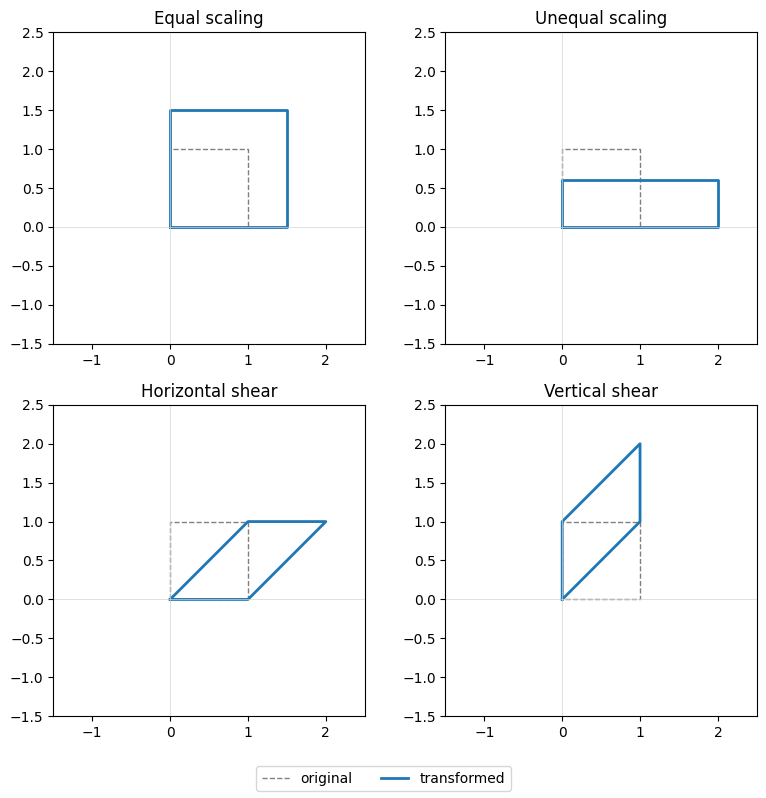

In [136]:
# Visual examples for the table above
def plot_square(ax, A, title):
    square = np.array([[0, 0, 1, 1, 0],
                       [0, 1, 1, 0, 0]])
    transformed = A @ square
    ax.plot(square[0], square[1], '--', color='gray', linewidth=1, label='original')
    ax.plot(transformed[0], transformed[1], color='C0', linewidth=2, label='transformed')
    ax.axhline(0, color='lightgray', linewidth=0.5)
    ax.axvline(0, color='lightgray', linewidth=0.5)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title)
    ax.set_xlim(-1.5, 2.5)
    ax.set_ylim(-1.5, 2.5)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
transforms = [
    (np.array([[1.5, 0], [0, 1.5]]), 'Equal scaling'),
    (np.array([[2.0, 0], [0, 0.6]]), 'Unequal scaling'),
    (np.array([[1, 1.0], [0, 1]]), 'Horizontal shear'),
    (np.array([[1, 0], [1.0, 1]]), 'Vertical shear')
]
for ax, (A_t, title) in zip(axes.ravel(), transforms):
    plot_square(ax, A_t, title)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)
plt.tight_layout(rect=[0, 0.05, 1, 1])

**Note:** These plots connect back to the earlier affine‑transformation notes: each matrix acts on the unit square the same way it acts on any vector, so you can visually see scaling and shearing while the eigenvector directions remain the axes that are preserved (when they exist).

## Segment 3: Matrix Operations for ML

### Singular Value Decomposition (SVD)

Unlike eigendecomposition, which is applicable to square matrices only, SVD is applicable to any real-valued matrix.
SVD decomposes matrix into:
- Singular vectors (analogous to eigenvectors)
- Singular values (analogous to eigenvalues)

$$A = UDV^T$$

**Matrix form (sizes $m\times n$):**
$$
A_{m\times n} = U_{m\times m} D_{m\times n} V_{n\times n}^T
$$

Where: 

* $U$ is an orthogonal $m \times m$ matrix; its columns are the **left-singular vectors** of $A$.
* $V$ is an orthogonal $n \times n$ matrix; its columns are the **right-singular vectors** of $A$ (Rows of $V^T$)
* $D$ is a diagonal $m \times n$ matrix; elements along its diagonal are the **singular values** of $A$.

**Singular values** are the non‑negative scalars on the diagonal of $D$ in $A=UDV^T$; they tell how much $A$ stretches along certain directions.  
**Singular vectors** are those directions: columns of $V$ (right‑singular vectors) in the input space and columns of $U$ (left‑singular vectors) in the output space.

In [137]:
A = np.array([[-1, 2], [3, -2], [5, 7]])
A

array([[-1,  2],
       [ 3, -2],
       [ 5,  7]])

In [138]:
U, d, VT = np.linalg.svd(A) # V is already transposed

In [139]:
U

array([[ 0.12708324,  0.47409506,  0.87125411],
       [ 0.00164602, -0.87847553,  0.47778451],
       [ 0.99189069, -0.0592843 , -0.11241989]])

In [140]:
VT

array([[ 0.55798885,  0.82984845],
       [-0.82984845,  0.55798885]])

In [141]:
d

array([8.66918448, 4.10429538])

In [142]:
np.diag(d)

array([[8.66918448, 0.        ],
       [0.        , 4.10429538]])

$D$ must have the same dimensions as $A$ for $UDV^T$ matrix multiplication to be possible: 

In [143]:
D = np.concatenate((np.diag(d), [[0, 0]]), axis=0)
D

array([[8.66918448, 0.        ],
       [0.        , 4.10429538],
       [0.        , 0.        ]])

In [144]:
np.dot(U, np.dot(D, VT))

array([[-1.,  2.],
       [ 3., -2.],
       [ 5.,  7.]])

SVD and eigendecomposition are closely related to each other: 

* Left-singular vectors of $A$ = eigenvectors of $AA^T$.
* Right-singular vectors of $A$ = eigenvectors of $A^TA$.
* Non-zero singular values of $A$ = square roots of eigenvalues of $AA^T$ = square roots of eigenvalues of $A^TA$

**Exercise**: Using the matrix `P` from the preceding PyTorch exercises, demonstrate that these three SVD-eigendecomposition equations are true. 

### Image Compression via SVD

The section features code adapted from [Frank Cleary's](https://gist.github.com/frankcleary/4d2bd178708503b556b0).

In [145]:
from PIL import Image

Fetch photo of Oboe, a terrier, with the book *Deep Learning Illustrated*: 

In [146]:
! wget https://raw.githubusercontent.com/jonkrohn/DLTFpT/master/notebooks/oboe-with-book.jpg

--2026-02-18 18:25:37--  https://raw.githubusercontent.com/jonkrohn/DLTFpT/master/notebooks/oboe-with-book.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8000::154, 2606:50c0:8003::154, 2606:50c0:8002::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8000::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 419564 (410K) [image/jpeg]
Saving to: ‘oboe-with-book.jpg.2’

oboe-with-book.jpg. 100%[===================>] 409.73K  1.13MB/s    in 0.4s    

2026-02-18 18:25:38 (1.13 MB/s) - ‘oboe-with-book.jpg.2’ saved [419564/419564]



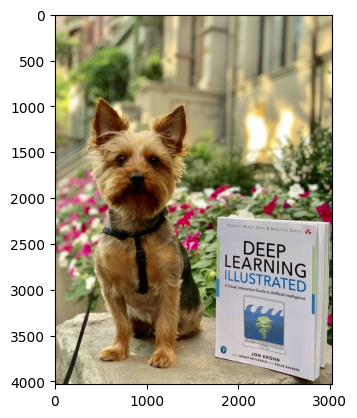

In [147]:
img = Image.open('oboe-with-book.jpg')
_ = plt.imshow(img)

Convert image to grayscale so that we don't have to deal with the complexity of multiple color channels: 

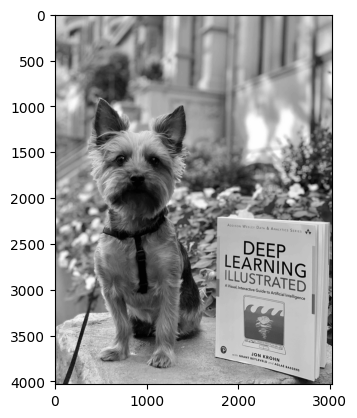

In [148]:
imggray = img.convert('LA')
_ = plt.imshow(imggray)

Convert data into numpy matrix, which doesn't impact image data: 

For images, NumPy arrays usually have shape:

(height, width, channels)


: → select all rows

: → select all columns

0 → select the first channel

So [:, :, 0] means:

“Take the entire image, but only the first color channel.”

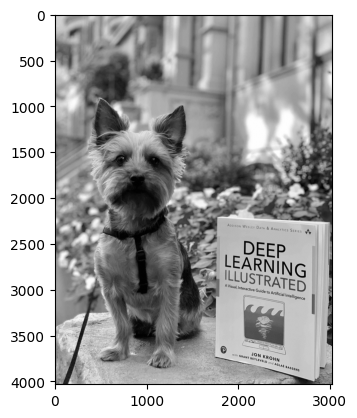

In [149]:
#imgmat = np.array(list(imggray.getdata(band=0)), float)
imgmat = np.asarray(imggray, dtype=float)[:, :, 0] # convert to 2D array and select the first (and only) channel, which is the grayscale values
imgmat.shape = (imggray.size[1], imggray.size[0])
imgmat = np.matrix(imgmat)
_ = plt.imshow(imgmat, cmap='gray')

Calculate SVD of the image: 

In [150]:
U, sigma, V = np.linalg.svd(imgmat)

As eigenvalues are arranged in descending order in diag($\lambda$) so too are singular values, by convention, arranged in descending order in $D$ (or, in this code, diag($\sigma$)). Thus, the first left-singular vector of $U$ and first right-singular vector of $V$ may represent the most prominent feature of the image: 

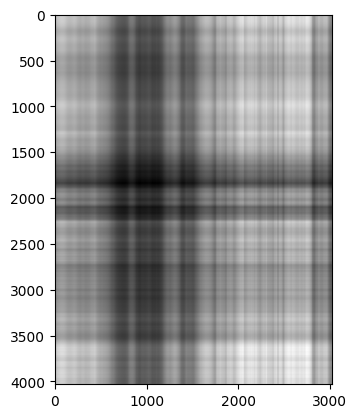

In [151]:
reconstimg = np.matrix(U[:, :1]) * np.diag(sigma[:1]) * np.matrix(V[:1, :]) # Checking inner dimensions means verifying that the number of columns of the first matrix equals the number of rows of the second, so multiplication is mathematically valid.
_ = plt.imshow(reconstimg, cmap='gray')

Additional singular vectors improve the image quality: 

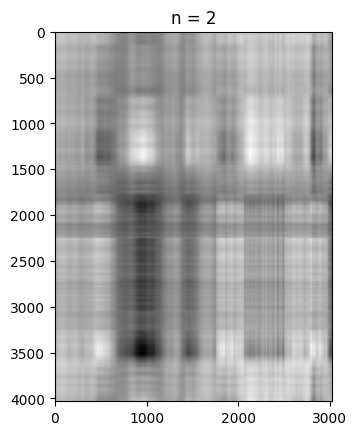

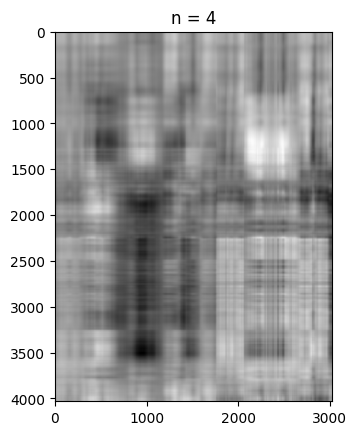

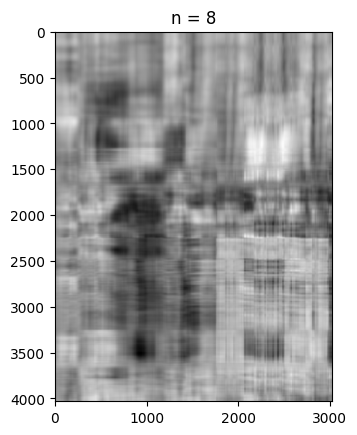

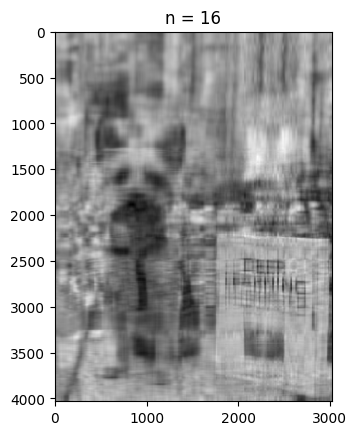

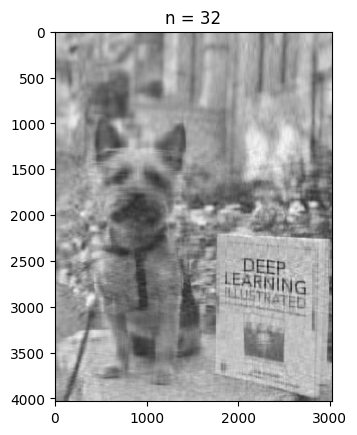

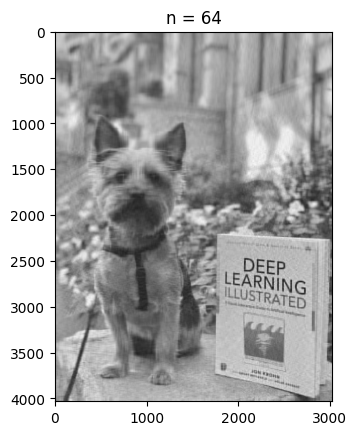

In [152]:
for i in [2, 4, 8, 16, 32, 64]:
    reconstimg = np.matrix(U[:, :i]) * np.diag(sigma[:i]) * np.matrix(V[:i, :])
    plt.imshow(reconstimg, cmap='gray')
    title = "n = %s" % i
    plt.title(title)
    plt.show()

With 64 singular vectors, the image is reconstructed quite well, however the data footprint is much smaller than the original image:

In [153]:
imgmat.shape

(4032, 3024)

In [154]:
full_representation = 4032*3024
full_representation

12192768

`4032*3024` is the total pixel count of the grayscale image (height × width), i.e., the full data size.

`svd64_rep = 64*4032 + 64 + 64*3024` counts parameters for a rank‑64 SVD:
- `U` uses $m \times k = 4032 \times 64$
- `\Sigma` uses $k = 64$
- `V` uses $k \times n = 64 \times 3024$

In [155]:
svd64_rep = 64*4032 + 64 + 64*3024
svd64_rep

451648

In [156]:
svd64_rep/full_representation

0.037042286050222556

Specifically, the image represented as 64 singular vectors is 3.7% of the size of the original! 

Alongside images, we can use singular vectors for dramatic, lossy compression of other types of media files.

**Return to slides here.**

### The Moore-Penrose Pseudoinverse

A matrix is invertible if it is square and non‑singular, i.e., its determinant is non‑zero (equivalently, it has full rank and its columns are linearly independent).

If a matrix isn’t square or is singular, it has no true inverse, so the Moore–Penrose pseudoinverse is used (e.g., for least‑squares solutions).

For a square non‑singular matrix $A$, the Moore–Penrose pseudoinverse equals the usual inverse: $A^+ = A^{-1}$.

**Overdetermined vs. underdetermined (what is minimized?)**

- **Overdetermined** (more equations than unknowns): there may be no exact solution, so we choose the line/weights that make the total error as small as possible. This means minimizing the **residual** $\|Ax-b\|_2$ (the sum of squared vertical errors).

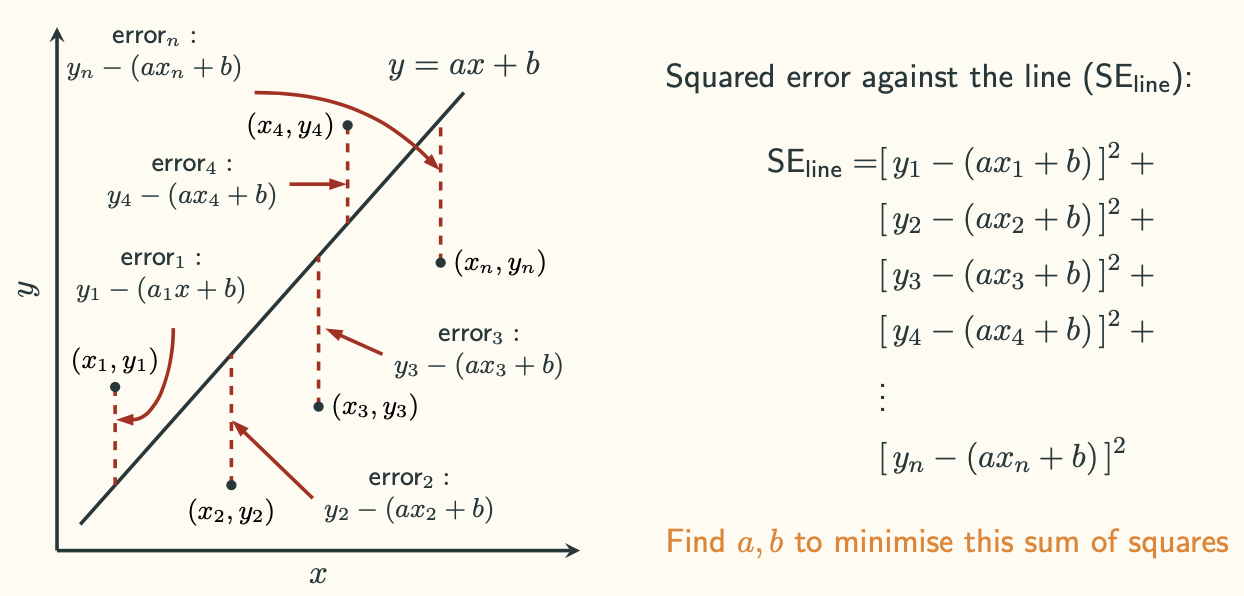

- **Underdetermined** (more unknowns than equations): there are infinitely many exact solutions, so we choose the **smallest‑length** solution. This means minimizing $\|x\|_2$ (the smallest‑norm set of weights) among all exact fits.
  - *Numeric example:* solve $x+y=1$. Solutions include $(1,0)$ and $(0,1)$, both exact. The smallest‑norm solution is $(0.5, 0.5)$ because it minimizes $\|x\|_2 = \sqrt{x^2+y^2}$.

Let's calculate the pseudoinverse $A^+$ of some matrix $A$ using the formula from the slides: 

$A^+ = VD^+U^T$

In [158]:
A = np.array([[-1, 2], [3, -2], [5, 7]])
A

array([[-1,  2],
       [ 3, -2],
       [ 5,  7]])

As shown earlier, the NumPy SVD method returns $U$, $d$, and $V^T$:

In [159]:
U, d, VT = np.linalg.svd(A)

In [160]:
U

array([[ 0.12708324,  0.47409506,  0.87125411],
       [ 0.00164602, -0.87847553,  0.47778451],
       [ 0.99189069, -0.0592843 , -0.11241989]])

In [161]:
VT

array([[ 0.55798885,  0.82984845],
       [-0.82984845,  0.55798885]])

In [162]:
d

array([8.66918448, 4.10429538])

To create $D^+$, we first invert the non-zero values of $d$: 

In [163]:
D = np.diag(d)
D

array([[8.66918448, 0.        ],
       [0.        , 4.10429538]])

In [164]:
1/8.669

0.11535355865728457

In [165]:
1/4.104

0.24366471734892786

...and then we would take the tranpose of the resulting matrix.

Because $D$ is a diagonal matrix, this can, however, be done in a single step by inverting $D$: 

In [166]:
Dinv = np.linalg.inv(D)
Dinv

array([[0.1153511 , 0.        ],
       [0.        , 0.24364718]])

$D^+$ must have the same dimensions as $A^T$ in order for $VD^+U^T$ matrix multiplication to be possible: 

In [167]:
Dplus = np.concatenate((Dinv, np.array([[0, 0]]).T), axis=1)
Dplus

array([[0.1153511 , 0.        , 0.        ],
       [0.        , 0.24364718, 0.        ]])

(Recall $D$ must have the same dimensions as $A$ for SVD's $UDV^T$, but for MPP $U$ and $V$ have swapped sides around the diagonal matrix.)

Now we have everything we need to calculate $A^+$ with $VD^+U^T$: 

In [168]:
np.dot(VT.T, np.dot(Dplus, U.T))

array([[-0.08767773,  0.17772512,  0.07582938],
       [ 0.07661927, -0.1192733 ,  0.08688784]])

Working out this derivation is helpful for understanding how Moore-Penrose pseudoinverses work, but unsurprisingly NumPy is loaded with an existing method `pinv()`: 

In [169]:
np.linalg.pinv(A)

array([[-0.08767773,  0.17772512,  0.07582938],
       [ 0.07661927, -0.1192733 ,  0.08688784]])

**Exercise** 

Use the `torch.svd()` method to calculate the pseudoinverse of `A_p`, confirming that your result matches the output of `torch.pinverse(A_p)`: 

In [170]:
A_p = torch.tensor([[-1, 2], [3, -2], [5, 7.]])
A_p

tensor([[-1.,  2.],
        [ 3., -2.],
        [ 5.,  7.]])

In [171]:
torch.pinverse(A_p)

tensor([[-0.0877,  0.1777,  0.0758],
        [ 0.0766, -0.1193,  0.0869]])

**Return to slides here.**

For regression problems, we typically have many more cases ($n$, or rows of $X$) than features to predict (columns of $X$). Let's solve a miniature example of such an overdetermined situation. 

We have eight data points ($n$ = 8): 

In [172]:
x1 = [0, 1, 2, 3, 4, 5, 6, 7.] # E.g.: Dosage of drug for treating Alzheimer's disease
y = [1.86, 1.31, .62, .33, .09, -.67, -1.23, -1.37] # E.g.: Patient's "forgetfulness score"

In [173]:
title = 'Clinical Trial'
xlabel = 'Drug dosage (mL)'
ylabel = 'Forgetfulness'

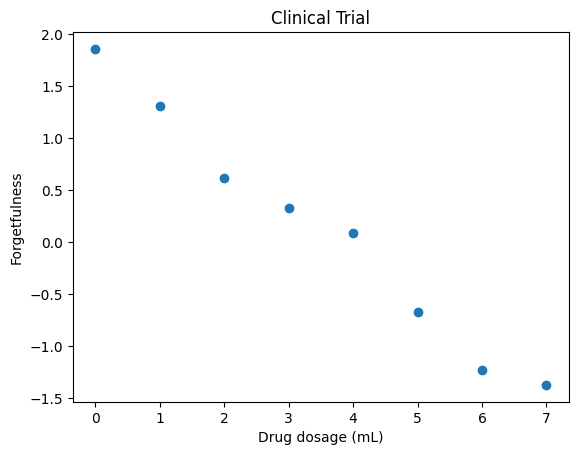

In [174]:
fig, ax = plt.subplots()
plt.title(title)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
_ = ax.scatter(x1, y)

Although we only see one feature ($x_1$), the linear model still needs an intercept (bias) term. We add a constant feature $x_0$ so the model can learn the $y$‑intercept instead of being forced through $(0,0)$. With this extra column, the model becomes
$$y = w_0 x_0 + w_1 x_1 = b + m x_1,$$
where $x_0$ is always $1$. That’s why we set $x_0 = 1$ for every data point: it turns the intercept into a learnable parameter.

**When do we need an intercept?** Include it unless you have a strong reason the line must pass through $(0,0)$. Most real datasets need a baseline shift, so the intercept helps fit that.

**When can we skip it?** Only when theory or design forces $y=0$ at $x=0$ (pure proportionality), or when you deliberately center the data and want the model to pass through the origin.

In [175]:
x0 = np.ones(8)
x0

array([1., 1., 1., 1., 1., 1., 1., 1.])

Concatenate $x_0$ and $x_1$ into a matrix $X$: 

In [176]:
#X = np.concatenate((np.matrix(x0).T, np.matrix(x1).T), axis=1)
# or
# X = np.array([x0, x1]).T
# or
# X = np.concatenate((np.array(x0).reshape(-1, 1), np.array(x1).reshape(-1, 1)), axis=1)
# or
X = np.column_stack((x0, x1))
X

array([[1., 0.],
       [1., 1.],
       [1., 2.],
       [1., 3.],
       [1., 4.],
       [1., 5.],
       [1., 6.],
       [1., 7.]])

From the slides, we know that we can calculate the weights $w$ using the equation 
$$
w = X^+y
$$
when 
$$
n \ne m
$$

Remember this for matrices with inverse: 

$$
w = X^{-1}y 
$$
when
$$
n = m
$$
when having exactly as many cases $n$ as the features $m$ 



In [177]:
w = np.dot(np.linalg.pinv(X), y)
w

array([ 1.76      , -0.46928571])

The first weight corresponds to the $y$-intercept of the line, which is typically denoted as $b$: 

In [178]:
b = w[0]
b

1.7599999999999985

While the second weight corresponds to the slope of the line, which is typically denoted as $m$: 

In [179]:
m = w[1]
m

-0.4692857142857139

With the weights we can plot the line to confirm it fits the points: 

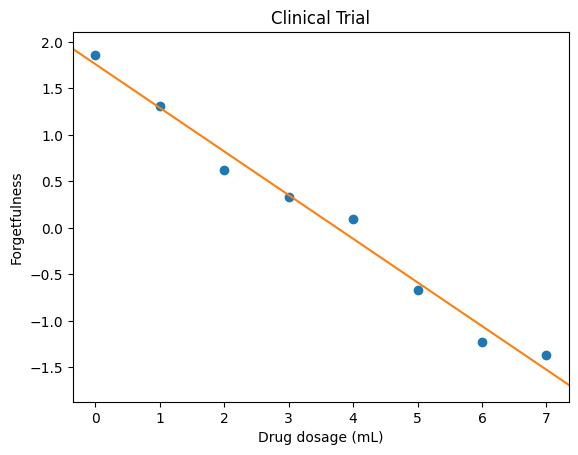

In [180]:
fig, ax = plt.subplots()

plt.title(title)
plt.xlabel(xlabel)
plt.ylabel(ylabel)

ax.scatter(x1, y)

x_min, x_max = ax.get_xlim()
y_at_xmin = m*x_min + b
y_at_xmax = m*x_max + b

ax.set_xlim([x_min, x_max])
_ = ax.plot([x_min, x_max], [y_at_xmin, y_at_xmax], c='C01')

**DO NOT return to slides here. Onward!**

### The Trace Operator

Denoted as Tr($A$). Simply the sum of the diagonal elements of a matrix: $$\sum_i A_{i,i}$$

In [181]:
A = np.array([[25, 2], [5, 4]])
A

array([[25,  2],
       [ 5,  4]])

In [182]:
25 + 4

29

In [183]:
np.trace(A)

29

The trace operator has a number of useful properties that come in handy while rearranging linear algebra equations, e.g.:

* Tr($A$) = Tr($A^T$)
* Assuming the matrix shapes line up: Tr($ABC$) = Tr($CAB$) = Tr($BCA$)

In particular, the trace operator can provide a convenient way to calculate a matrix's Frobenius norm: $$||A||_F = \sqrt{\mathrm{Tr}(AA^\mathrm{T})}$$

**Exercises**

With the matrix `A_p` provided below: 

1. Use the PyTorch trace method to calculate the trace of `A_p`.
2. Use the PyTorch Frobenius norm method and the trace method to demonstrate that $||A||_F = \sqrt{\mathrm{Tr}(AA^\mathrm{T})}$

In [184]:
A_p

tensor([[-1.,  2.],
        [ 3., -2.],
        [ 5.,  7.]])

**Return to slides here.**

### Principal Component Analysis

This PCA example code is adapted from [here](https://jupyter.brynmawr.edu/services/public/dblank/CS371%20Cognitive%20Science/2016-Fall/PCA.ipynb).

In [213]:
from sklearn import datasets
iris = datasets.load_iris()

In [201]:
iris.data.shape

(150, 4)

In [202]:
iris.get("feature_names")

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [203]:
iris.data[0:6,:]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4]])

In [211]:
from sklearn.decomposition import PCA

In [212]:
pca = PCA(n_components=2)

In [206]:
X = pca.fit_transform(iris.data)

In [207]:
X.shape

(150, 2)

In [208]:
X[0:6,:]

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045]])

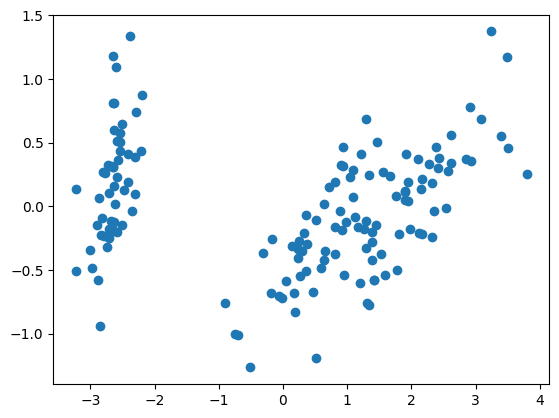

In [209]:
_ = plt.scatter(X[:, 0], X[:, 1])

In [195]:
iris.target.shape

(150,)

In [196]:
iris.target[0:6]

array([0, 0, 0, 0, 0, 0])

In [197]:
unique_elements, counts_elements = np.unique(iris.target, return_counts=True)
np.asarray((unique_elements, counts_elements))

array([[ 0,  1,  2],
       [50, 50, 50]])

In [198]:
list(iris.target_names)

['setosa', 'versicolor', 'virginica']

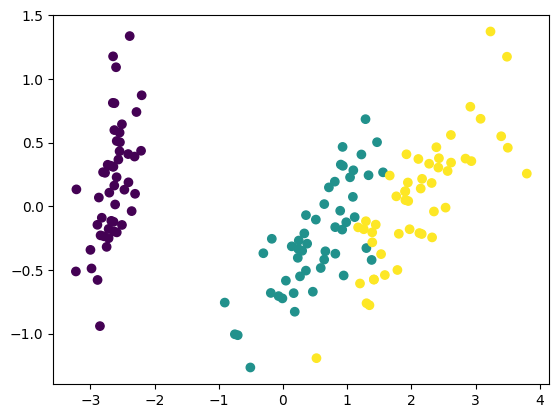

In [199]:
_ = plt.scatter(X[:, 0], X[:, 1], c=iris.target)

**Return to slides here.**